# 🎯 Análise de Centralidade - Game of Thrones
## Quem é matematicamente o personagem mais importante?

In [10]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
import numpy as np

In [ ]:
df = pd.read_csv("../datasets/interacoes.csv")
df_direct = df[df["tipo_interacao"] == "single"]
df_grouped = df_direct.groupby(['falante', 'ouvinte']).size().reset_index(name='weight')
G = nx.from_pandas_edgelist(df_grouped, 'falante', 'ouvinte', edge_attr='weight', create_using=nx.Graph())
print(f"✅ Grafo: {G.number_of_nodes()} nós, {G.number_of_edges()} arestas")

✅ Grafo: 138 nós, 1091 arestas


## 1️⃣ Centralidade de Grau

In [12]:
degree_cent = nx.degree_centrality(G)
top_degree = sorted(degree_cent.items(), key=lambda x: x[1], reverse=True)[:10]
pd.DataFrame(top_degree, columns=['Personagem', 'Score'])

,Personagem,Score
0,JOFFREY BARATHEON,0.518248
1,TYRION LANNISTER,0.452555
2,CATELYN STARK,0.408759
3,BRIENNE DE TARTH,0.401460
4,JAIME LANNISTER,0.357664
5,DAENERYS TARGARYEN,0.343066
6,THEON GREYJOY,0.313869
7,DAISY,0.306569
8,SANSA STARK,0.291971
9,BOWEN MARSH,0.277372


## 2️⃣ Centralidade de Intermediação

In [13]:
betweenness_cent = nx.betweenness_centrality(G, weight='weight')
top_betweenness = sorted(betweenness_cent.items(), key=lambda x: x[1], reverse=True)[:10]
pd.DataFrame(top_betweenness, columns=['Personagem', 'Score'])

,Personagem,Score
0,BRIENNE DE TARTH,0.215457
1,JOFFREY BARATHEON,0.122996
2,DAISY,0.108345
3,JAIME LANNISTER,0.071066
4,WALDA BOLTON,0.068387
5,CAMELLO,0.065370
6,DAENERYS TARGARYEN,0.065264
7,GREY WORM,0.063426
8,AXELL FLORENT,0.055914
9,PODRICK PAYNE,0.052215


## 3️⃣ PageRank

In [14]:
pagerank = nx.pagerank(G, weight='weight')
top_pagerank = sorted(pagerank.items(), key=lambda x: x[1], reverse=True)[:10]
pd.DataFrame(top_pagerank, columns=['Personagem', 'Score'])

,Personagem,Score
0,TYRION LANNISTER,0.059793
1,JOFFREY BARATHEON,0.052936
2,CATELYN STARK,0.037560
3,DAENERYS TARGARYEN,0.036395
4,JAIME LANNISTER,0.029741
5,SANSA STARK,0.028055
6,BRIENNE DE TARTH,0.027030
7,ARYA STARK,0.026170
8,THEON GREYJOY,0.025752
9,SAMWELL TARLY,0.024931


## 4️⃣ Eigenvector Centrality

In [15]:
try:
    eigenvector_cent = nx.eigenvector_centrality(G, weight='weight', max_iter=1000)
except:
    eigenvector_cent = nx.eigenvector_centrality(G, max_iter=1000)
top_eigenvector = sorted(eigenvector_cent.items(), key=lambda x: x[1], reverse=True)[:10]
pd.DataFrame(top_eigenvector, columns=['Personagem', 'Score'])

,Personagem,Score
0,TYRION LANNISTER,0.574559
1,JOFFREY BARATHEON,0.328309
2,JAIME LANNISTER,0.314087
3,BRIENNE DE TARTH,0.312903
4,CATELYN STARK,0.278643
5,DAENERYS TARGARYEN,0.254390
6,SANSA STARK,0.182932
7,VARYS,0.178988
8,TYWIN LANNISTER,0.144013
9,JORAH MORMONT,0.125307


## 5️⃣ Weighted Degree

In [16]:
weighted_degree = dict(G.degree(weight='weight'))
top_weighted = sorted(weighted_degree.items(), key=lambda x: x[1], reverse=True)[:10]
pd.DataFrame(top_weighted, columns=['Personagem', 'Interações'])

,Personagem,Interações
0,TYRION LANNISTER,2614
1,JOFFREY BARATHEON,2129
2,CATELYN STARK,1476
3,DAENERYS TARGARYEN,1473
4,JAIME LANNISTER,1250
5,BRIENNE DE TARTH,1140
6,SANSA STARK,1131
7,ARYA STARK,1046
8,THEON GREYJOY,898
9,SAMWELL TARLY,857


## 🏆 Ranking Consolidado
**Pesos:** PageRank(40%), Betweenness(30%), Weighted Degree(20%), Eigenvector(10%)

In [17]:
personagens = list(degree_cent.keys())
scaler = MinMaxScaler()

norm_pr = scaler.fit_transform(np.array([pagerank[p] for p in personagens]).reshape(-1,1)).flatten()
norm_bt = scaler.fit_transform(np.array([betweenness_cent[p] for p in personagens]).reshape(-1,1)).flatten()
norm_wd = scaler.fit_transform(np.array([weighted_degree[p] for p in personagens]).reshape(-1,1)).flatten()
norm_ev = scaler.fit_transform(np.array([eigenvector_cent.get(p, 0) for p in personagens]).reshape(-1,1)).flatten()

scores = {p: norm_pr[i]*0.4 + norm_bt[i]*0.3 + norm_wd[i]*0.2 + norm_ev[i]*0.1 for i,p in enumerate(personagens)}
top = sorted(scores.items(), key=lambda x: x[1], reverse=True)[:20]

df_final = pd.DataFrame([
    (p, scores[p], pagerank[p], betweenness_cent[p], weighted_degree[p], eigenvector_cent.get(p, 0)) 
    for p,_ in top
], columns=["Personagem","Score","PageRank","Betweenness","W_Degree","Eigenvector"])

df_final

,Personagem,Score,PageRank,Betweenness,W_Degree,Eigenvector
0,TYRION LANNISTER,0.757590,0.059793,0.041361,2614,0.574559
1,JOFFREY BARATHEON,0.744452,0.052936,0.122996,2129,0.328309
2,BRIENNE DE TARTH,0.617969,0.027030,0.215457,1140,0.312903
3,DAENERYS TARGARYEN,0.488076,0.036395,0.065264,1473,0.254390
4,CATELYN STARK,0.455243,0.037560,0.032778,1476,0.278643
5,JAIME LANNISTER,0.444054,0.029741,0.071066,1250,0.314087
6,DAISY,0.368041,0.021182,0.108345,821,0.103511
7,SANSA STARK,0.346679,0.028055,0.032334,1131,0.182932
8,ARYA STARK,0.326689,0.026170,0.044729,1046,0.080245
9,THEON GREYJOY,0.298827,0.025752,0.037056,898,0.063065


## 📊 Visualização

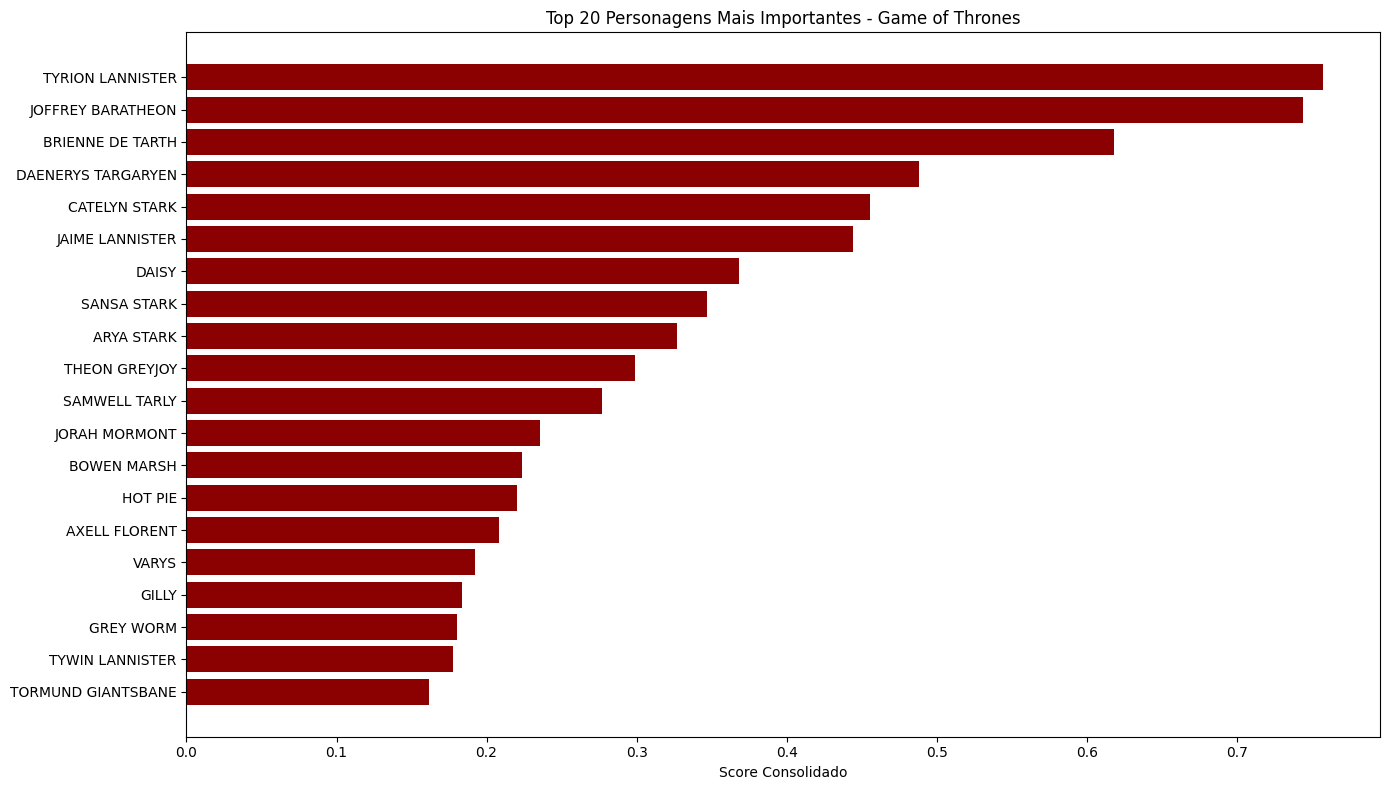

In [18]:
plt.figure(figsize=(14,8))
plt.barh(df_final["Personagem"], df_final["Score"], color="darkred")
plt.xlabel("Score Consolidado")
plt.title("Top 20 Personagens Mais Importantes - Game of Thrones")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()